# The goal with this analysis is to show correlation between LASV ELISA seropositivity and LASV peptides PHIP-Seq enrichment. Will compare 1. strength of ELISA seropositivity to glycoprotein to enrichment of glycoprotein peptides, 2. strenght of ELISA seropositivity to nucleoprotein to enrichment of nucleoprotein peptides, and overall concordance of ELISA seropositivity with enrichment of LASV peptides. 

In [1]:
import pandas as pd

meta_elisa = pd.read_csv('./files/LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv')

meta_peps = pd.read_csv('./files/lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')

filtered_peps = pd.read_csv('./files/pep_hits_sen_spec_092326.csv')

long = pd.read_csv('./files/long_092326_senspec.csv')

meta_elisa = meta_elisa.drop(columns=['Unnamed: 0'])

filtered_peps = filtered_peps.drop(columns=['Unnamed: 0'])

## keep only important columns

In [2]:
cols_to_keep = ['species', 'individual', 'cohort', 'Sample', 'NP_Calc_Conc', 'NP_FINAL_RESULT', 
                'GP_Calc_Conc', 'GP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']

In [3]:
meta_elisa = meta_elisa[cols_to_keep]

## filtering to LASV glycoprotein only peptides

In [4]:
long_lasv_gp = long.loc[(long['species'] == 'Mammarenavirus lassaense') & (long['protein_std'] == 'glycoprotein')]

long_lasv_gp = long_lasv_gp.merge(meta_elisa[['individual', 'GP_Calc_Conc', 'GP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

## Q: do individuals who are GP-seropositive show greater GP peptide reactivity by PhIP-Seq than GP-seronegative individuals? 

In [5]:
# collapsing number of reactive glycoprotein peptides per individual
gp_individual = (
    long_lasv_gp.groupby('individual')
    .agg(
        gp_serology=('GP_FINAL_RESULT', 'first'), 
        gp_conc = ('GP_Calc_Conc', 'first'), 
        n_gp_peptides=('reactive', 'size'), 
        n_reactive_gp=('reactive', 'sum'), 
        frac_reactive_gp=('reactive', 'mean')
    ).reset_index()
)

gp_individual.head(8)

,individual,gp_serology,gp_conc,n_gp_peptides,n_reactive_gp,frac_reactive_gp
0,C-109-1_5_B3,Negative,1.835048,17,0,0.000000
1,C-109-2_5_B5,Negative,1.972705,17,0,0.000000
2,C-109-3_4_E7,Positive,23.858109,17,9,0.529412
3,C-110-1_2_A5,Negative,2.629727,17,0,0.000000
4,C-110-2_3_F8,Positive,3.588056,17,2,0.117647
5,C-110-3_2_E6,Negative,2.524546,17,0,0.000000
6,C-111-1_2_H8,Positive,3.364582,17,1,0.058824
7,C-111-2_3_I5,Positive,9.011087,17,0,0.000000


### Binary concordance - first defining positivity as having at leas one reactive GP peptide

In [6]:
gp_individual['PhIP_gp_positive'] = gp_individual['n_reactive_gp'] > 0

In [7]:
from scipy.stats import fisher_exact

table = pd.crosstab(gp_individual['PhIP_gp_positive'], gp_individual['gp_serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

gp_serology       Negative  Positive
PhIP_gp_positive                    
False                   68        86
True                    80       163
Odds ratio 1.611046511627907
Fisher exact p 0.025742892369453693


### Comparing the amount of GP peptide recognition and GP Serology status

In [8]:
from scipy.stats import mannwhitneyu

positive = gp_individual.loc[(gp_individual['gp_serology'] == 'Positive'), 'n_reactive_gp']

negative = gp_individual.loc[(gp_individual['gp_serology'] == 'Negative'), 'n_reactive_gp']

stat, p_value = mannwhitneyu(
    positive, 
    negative, 
    alternative='two-sided'
)

print('Mann-Whitney U', stat)
print('p', p_value)

Mann-Whitney U 21253.5
p 0.008012735665494422


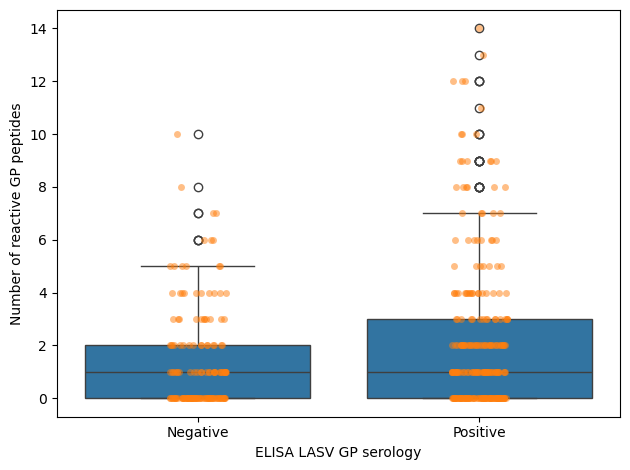

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=gp_individual, 
    x='gp_serology', 
    y='n_reactive_gp'
)

sns.stripplot(
    data=gp_individual, 
    x='gp_serology', 
    y='n_reactive_gp', 
    alpha=0.5
)

plt.xlabel('ELISA LASV GP serology')
plt.ylabel('Number of reactive GP peptides')
plt.tight_layout()
plt.show()

### look at number of reactive peptides and LASV NP IgG calculated concentration baed on 4PK regression, relative Units/mL and 

In [10]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    gp_individual['gp_conc'], 
    gp_individual['n_reactive_gp'], 
    nan_policy='omit'
)

print('Spearman rho', rho)
print('p', p_value)

Spearman rho 0.1516973258105519
p 0.0024408913145709215


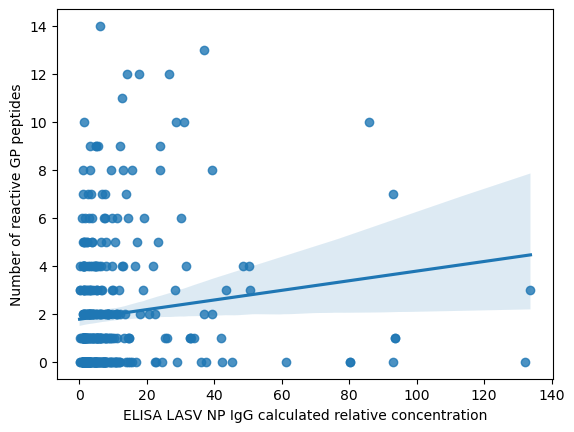

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=gp_individual, 
    x='gp_conc', 
    y='n_reactive_gp'
)

plt.xlabel('ELISA LASV NP IgG calculated relative concentration')
plt.ylabel('Number of reactive GP peptides')
plt.show()

## Now for nucleoprotein

In [12]:
long_lasv_np = long.loc[(long['species'] == 'Mammarenavirus lassaense') & (long['protein_std'] == 'nucleoprotein')]

long_lasv_np = long_lasv_gp.merge(meta_elisa[['individual', 'NP_Calc_Conc', 'NP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

In [13]:
# collapsing number of reactive glycoprotein peptides per individual
np_individual = (
    long_lasv_np.groupby('individual')
    .agg(
        np_serology=('GP_FINAL_RESULT', 'first'), 
        np_conc = ('GP_Calc_Conc', 'first'), 
        n_np_peptides=('reactive', 'size'), 
        n_reactive_np=('reactive', 'sum'), 
        frac_reactive_np=('reactive', 'mean')
    ).reset_index()
)

np_individual.head(8)

,individual,np_serology,np_conc,n_np_peptides,n_reactive_np,frac_reactive_np
0,C-109-1_5_B3,Negative,1.835048,17,0,0.000000
1,C-109-2_5_B5,Negative,1.972705,17,0,0.000000
2,C-109-3_4_E7,Positive,23.858109,17,9,0.529412
3,C-110-1_2_A5,Negative,2.629727,17,0,0.000000
4,C-110-2_3_F8,Positive,3.588056,17,2,0.117647
5,C-110-3_2_E6,Negative,2.524546,17,0,0.000000
6,C-111-1_2_H8,Positive,3.364582,17,1,0.058824
7,C-111-2_3_I5,Positive,9.011087,17,0,0.000000


In [14]:
np_individual['PhIP_np_positive'] = np_individual['n_reactive_np'] > 0

In [15]:
from scipy.stats import fisher_exact

table = pd.crosstab(np_individual['PhIP_np_positive'], np_individual['np_serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

np_serology       Negative  Positive
PhIP_np_positive                    
False                   68        86
True                    80       163
Odds ratio 1.611046511627907
Fisher exact p 0.025742892369453693


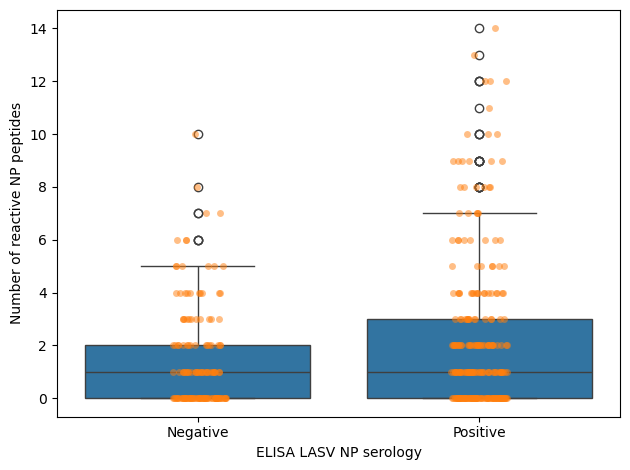

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=np_individual, 
    x='np_serology', 
    y='n_reactive_np'
)

sns.stripplot(
    data=np_individual, 
    x='np_serology', 
    y='n_reactive_np', 
    alpha=0.5
)

plt.xlabel('ELISA LASV NP serology')
plt.ylabel('Number of reactive NP peptides')
plt.tight_layout()
plt.show()

## now comparing all LASV PhIP-Seq reactivity to serostatus

In [17]:
long_lasv = long.loc[(long['species'] == 'Mammarenavirus lassaense')]

long_lasv= long_lasv.merge(meta_elisa[['individual', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

In [18]:
# collapsing number of reactive glycoprotein peptides per individual
individual = (
    long_lasv.groupby('individual')
    .agg(
        serology=('Serology_Result_Corrected', 'first'), 
        n_peptides=('reactive', 'size'), 
        n_reactive=('reactive', 'sum'), 
        frac_reactive=('reactive', 'mean')
    ).reset_index()
)

individual.head(8)

,individual,serology,n_peptides,n_reactive,frac_reactive
0,C-109-1_5_B3,Negative,258,24,0.093023
1,C-109-2_5_B5,Negative,258,16,0.062016
2,C-109-3_4_E7,Positive,258,26,0.100775
3,C-110-1_2_A5,Positive,258,9,0.034884
4,C-110-2_3_F8,Positive,258,13,0.050388
5,C-110-3_2_E6,Positive,258,12,0.046512
6,C-111-1_2_H8,Positive,258,31,0.120155
7,C-111-2_3_I5,Positive,258,11,0.042636


In [19]:
individual['PhIP_positive'] = individual['n_reactive'] > 0

In [20]:
from scipy.stats import fisher_exact

table = pd.crosstab(individual['PhIP_positive'], individual['serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

serology       Negative  Positive
PhIP_positive                    
True                 50       347
Odds ratio 1.0
Fisher exact p 1.0


In [21]:
from scipy.stats import mannwhitneyu

positive = individual.loc[(individual['serology'] == 'Positive'), 'n_reactive']

negative = individual.loc[(individual['serology'] == 'Negative'), 'n_reactive']

stat, p_value = mannwhitneyu(
    positive, 
    negative, 
    alternative='two-sided'
)

print('Mann-Whitney U', stat)
print('p', p_value)

Mann-Whitney U 11346.0
p 0.00042842069823150305


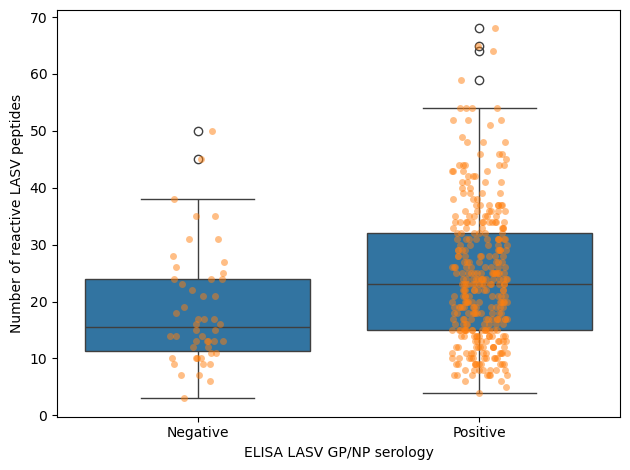

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=individual, 
    x='serology', 
    y='n_reactive'
)

sns.stripplot(
    data=individual, 
    x='serology', 
    y='n_reactive', 
    alpha=0.5
)

plt.xlabel('ELISA LASV GP/NP serology')
plt.ylabel('Number of reactive LASV peptides')
plt.tight_layout()
plt.show()